In [2]:
import simpy
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

### **AIRCRAFT QUEUING SYSTEM DISCRETE EVENT SIMULATION**

In [3]:
id_rul = np.array(range(1, 101))

pred_rul = np.array([155.17740722, 113.61686524,  66.08386757,  63.35103568,
        83.17437079,  83.12505288,  81.53717588,  61.14415514,
       117.77366698,  79.4728982 ,  87.61002972,  69.47066   ,
        75.79695929, 113.10346241, 115.25097745,  71.17512129,
        38.94871908,  69.27077992,  90.19410799,  47.13502051,
        40.46396586, 143.66322918,  75.42454329,  27.72430567,
       128.1305004 , 125.19042027,  75.9992773 ,  71.42252624,
        89.84496613,  62.97732754,  47.71663038,  20.1025816 ,
       113.6631011 ,  38.29091373,  44.96189628,  32.78901748,
        33.25506782,  32.81621508, 149.49425064,  45.99030562,
        57.73477685,  36.12013562,  48.35348892,  88.35298095,
        51.11216736,  36.17953899, 110.27852504, 117.83298277,
        49.68140262, 113.44814587,  43.37123389,  23.0794082 ,
        20.41572487, 100.3130299 ,  93.98410119,  46.12647563,
        58.66051857,  50.08798135, 121.29136636,  58.21252772,
        52.68323224,  38.11671871,  43.06787719,  41.07806244,
       147.44377571,  22.89117882, 118.36612987,  41.92224195,
       112.21508193,  64.7352367 , 115.27674718,  45.28011069,
       107.17763453,  67.15424907,  84.89941983,  38.99307282,
        49.99912312, 185.17536767,  74.61279707,  70.37832948,
        57.0341404 ,  35.26162815, 100.62049892,  43.38445091,
       135.51318301,  57.76567397, 147.1462627 , 107.05974032,
        77.35583005,  30.29931182,  40.70388794,  29.45492074,
        45.29104425,  49.23915175, 103.10290482, 123.34617942,
        49.60089105,  68.13844647, 107.30071852,  37.69929113])


class AircraftMaintenance:
    def __init__(self, pred_rul, id_rul, amt_server, amt_seed):

        self.amt_server = amt_server
        self.amt_seed = amt_seed
        self.pred_rul = pred_rul
        self.id_rul = id_rul

        self.customers_remaining = 0 

        self.all_data = {'server_num': [],
                        'seed_num': [],
                        'rmse': [],
                        'avg_wait_time': [],
                        'avg_queue_time': [],
                        'avg_queue_length': []}
        

    def run(self): 
        print (f'The simulation is programmed to run from 1 to {self.amt_server} repair shop(s), whereby each shop simulation is repeated'
                  f' {self.amt_seed} times to get accurate results')
        for i in range(1, self.amt_server + 1):
            
            np.random.seed(42)

            for x in range(1, self.amt_seed + 1):
                print('-------------------------------------------------------------------------------------------------------------------------------------------')
                print ('                                                                                             ')
                print(f'Repair with {i} repair shop(s). Seed number (iterative) is {x})')
                print ('                                                                                             ')
                
                self.wait_t = []
                self.queue_t = []
                self.obs_times = []
                self.n_length = []

                self.punished_rul = []
                self.reindexed_pred_rul = []
                
                np.random.seed(x)
                env = simpy.Environment()
                servers = simpy.PriorityResource(env, capacity = i)
                env.process(self.arrival_run(env, servers))
                env.process(self.observe(env, servers))
                env.run()
                
                indv_rmse = np.sqrt(np.mean((np.array(self.reindexed_pred_rul) - np.array(self.punished_rul)) ** 2))
                print(f'After using {i} Server(s), with seed number {x}, the RMSE is {indv_rmse}, with an avg waiting time of {np.mean(self.wait_t)}'
                f' and avaerage length of queue = {np.mean(self.n_length)}')
            

                self.all_data['server_num'].append(i)
                self.all_data['seed_num'].append(x)
                self.all_data['rmse'].append(indv_rmse)
                self.all_data['avg_wait_time'].append(np.mean(self.wait_t))
                #self.all_data['wait_time_std'].append(np.std(self.wait_t))
                self.all_data['avg_queue_time'].append(np.mean(self.queue_t))
                #self.all_data['queue_time_std'].append(np.std(self.queue_t))
                self.all_data['avg_queue_length'].append(np.mean(self.n_length))
                #self.all_data['queue_length_std'].append(np.std(self.n_length))
                
            
    
                print('==================================================================================================================================================')
                # In-Simulation Plots
                plt.figure()
                plt.hist(self.wait_t, bins = 20)
                plt.xlabel('Waiting Time (days)')
                plt.ylabel('Count of TUrbofan Engines')

                plt.figure()
                plt.hist(self.queue_t, bins = 20)
                plt.xlabel('Queue Time (days)')
                plt.ylabel('Count of TUrbofan Engines')
                    
                plt.figure()
                plt.step(self.obs_times, self.n_length, where = 'post')
                plt.xlabel('Time (days)')
                plt.ylabel('Queue Length')

               
                
                plt.show()
                # End of In-Simulation Plots
                
                    
        df = pd.DataFrame(self.all_data)
        fig, ax = plt.subplots()

        
        # Post-Simulation Plots
        df.groupby('server_num')['rmse'].mean().plot(ax=ax, marker='o', label = 'Simulation RMSE')
        ax.set_xlabel('Number of Servers')
        ax.set_ylabel('Average RMSE')
        ax.set_title('Average RMSE vs Number of Servers')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=26, color='red', linestyle='--', linewidth=2, label=f'LightGBM RMSE = {28.17}')
        ax.legend()
        plt.tight_layout()
        plt.show()
        
        plt.show()
        df.groupby('server_num')['avg_wait_time'].mean().plot()
        plt.xlabel('Number of Servers')
        plt.ylabel('Average Wait Time (days)')
        plt.title('Average Wait Time vs Servers')
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.figure()

        df.groupby('server_num')['avg_queue_time'].mean().plot()
        plt.xlabel('Number of Servers')
        plt.ylabel('Average Queue Time (days)')
        plt.title('Average Queue Time vs Servers')
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.figure()
        
        df.groupby('server_num')['avg_queue_length'].mean().plot()
        plt.xlabel('Number of Servers')
        plt.ylabel('Average Queue Length')
        plt.show()
        print('================================================================================================================================================')

    def generate_interarrival(self):
        inter_arrival = np.random.exponential(scale=11)
        return inter_arrival
    
    def get_repair_time(self, rul):
        if rul > 95:
            low_risk = np.random.triangular(45, 55, 65)  # Performance restoration
            return low_risk
        elif rul >= 49:
            medium = np.random.triangular(55, 60, 65)  # Full overhauling
            return medium
        else:
            high = 80  # LLP replacement 
            return high

    
    def arrival_run (self, env, servers):
        # The process achieves the repair of all 100 engines before returning to the for loop in the run method.
        i = -1
        while i < 99:
            i += 1
            #self.i.append(i)
            self.customers_remaining += 1  # Increment when customer arrives
            
            yield env.timeout(self.generate_interarrival())
            env.process(self.repair_run(env, i, servers))
        
   
            
    def repair_run (self, env, i, servers):
        t_arrival = env.now
        print (f'{env.now} turbofan {self.id_rul[i]} arrives, with a RUL of {self.pred_rul[i]}')

        wait_start = env.now
        
        
        with servers.request(priority = self.pred_rul[i]) as request:
                
            yield request 
            
            print (f'{env.now} turbofan ID {self.id_rul[i]} with RUL of {self.pred_rul[i]} is being repaired')
            repair_time = self.get_repair_time(self.pred_rul[i])
            start_repair = env.now
            yield env.timeout(repair_time)
            
            print(f'Repair time for turbofan of {self.id_rul[i]}, having RUL of {self.pred_rul[i]} is {repair_time}')
            print (f'{env.now} turbofan {self.id_rul[i]} repair completed. spent {start_repair - wait_start} days on queue,'
                   f'and {env.now - t_arrival} days in repair shop')
        
            
            t_depart = env.now
            queue_waiting = start_repair - wait_start
            total_waiting = t_depart - t_arrival
            self.queue_t.append(queue_waiting)  
            self.wait_t.append(total_waiting)   
            self.customers_remaining -= 1  # Decrement when customer leaves
            

            degradation = queue_waiting * 24/7.5
            punished_rul = max(self.pred_rul[i] - degradation, 0)
            
                
            self.punished_rul.append(punished_rul)
            self.reindexed_pred_rul.append(self.pred_rul[i])
        
                         
    
    def observe (self, env, servers):
        while self.customers_remaining > 0 or len(servers.queue) > 0:  # Stop when no customers left
    
            self.obs_times.append(env.now)
            self.n_length.append(len(servers.queue))
            yield env.timeout(0.5)
            

In [4]:
sim = AircraftMaintenance(pred_rul, id_rul, 17, 10)

In [13]:
#sim.run()

In [6]:
df = pd.DataFrame(sim.all_data)

In [14]:
df

,server_num,seed_num,rmse,avg_wait_time,avg_queue_time,avg_queue_length
0,1,1,80.478318,3038.665216,2973.958246,45.916242
1,1,2,80.692190,3076.629815,3011.863233,46.456502
2,1,3,80.485458,3080.178058,3014.754040,46.015722
3,1,4,80.693553,3018.706656,2953.057921,44.727300
4,1,5,80.362247,2988.664805,2923.187467,44.624227
...,...,...,...,...,...,...
165,17,6,0.000000,65.009716,0.000000,0.000000
166,17,7,0.000000,65.126102,0.000000,0.000000
167,17,8,0.000000,65.060056,0.000000,0.000000
168,17,9,0.000000,65.364166,0.000000,0.000000


In [8]:
df_grouped = df.groupby('server_num').agg({
    'rmse': ['mean', 'std'],
    'avg_wait_time': ['mean', 'std'],
    'avg_queue_time': ['mean', 'std'],
    'avg_queue_length': ['mean', 'std']
}).reset_index()


### Refined Plots

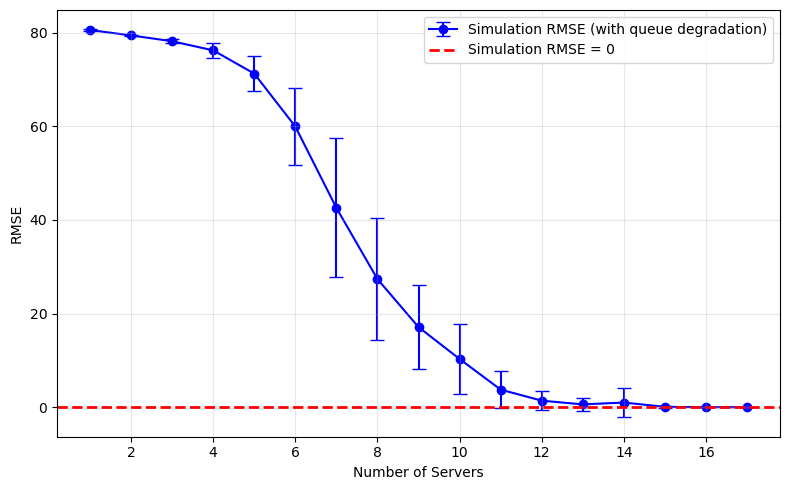

In [15]:
df_grouped = df.groupby('server_num').agg({
    'rmse': ['mean', 'std'],
    'avg_wait_time': ['mean', 'std'],
    'avg_queue_time': ['mean', 'std'],
    'avg_queue_length': ['mean', 'std']
}).reset_index()

df_grouped.columns = ['server_num', 'rmse_mean', 'rmse_std', 
                      'wait_mean', 'wait_std', 
                      'queue_time_mean', 'queue_time_std',
                      'queue_len_mean', 'queue_len_std']

fig, ax = plt.subplots(figsize=(8, 5))


ax.errorbar(df_grouped['server_num'], df_grouped['rmse_mean'], 
            yerr=df_grouped['rmse_std'], marker='o', capsize=5, 
            label='Simulation RMSE (with queue degradation)', color='blue', zorder = 1)

ax.axhline(y=0, color='red', linestyle='--', linewidth=2, 
           label=f'Simulation RMSE = 0', zorder = 2)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])  # Reverse the order

ax.set_xlabel('Number of Servers')
ax.set_ylabel('RMSE')
#ax.set_title('Impact of Server Capacity on Prediction Error')
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('rmse_vs_servers.png', dpi=150)
plt.show()



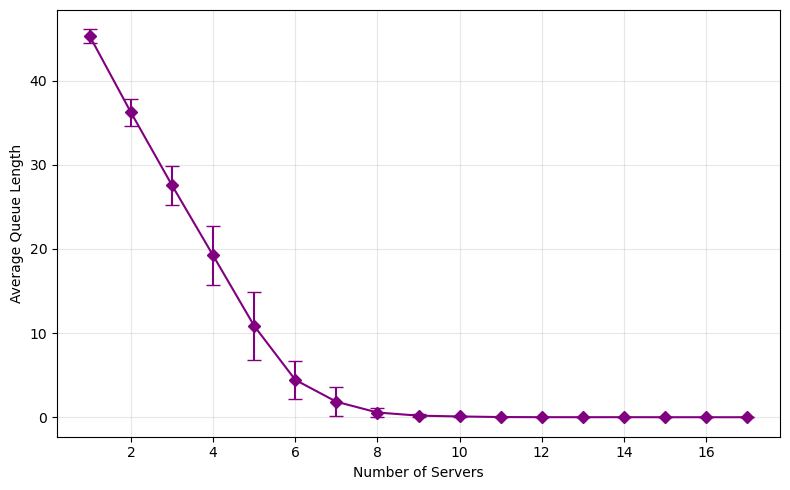

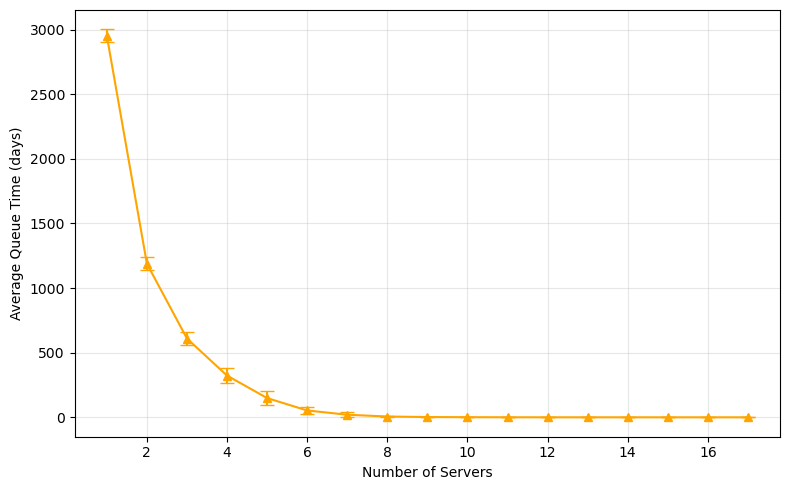

In [16]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.errorbar(df_grouped['server_num'], df_grouped['queue_len_mean'], 
            yerr=df_grouped['queue_len_std'], marker='D', capsize=5, color='purple')
ax1.set_xlabel('Number of Servers')
ax1.set_ylabel('Average Queue Length')
#ax1.set_title('Queue Length vs Number of Servers')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('queue_len_vs_servers.png', dpi=150)
plt.show()

fig, ax2 = plt.subplots(figsize=(8, 5))
ax2.errorbar(df_grouped['server_num'], df_grouped['queue_time_mean'], 
             yerr=df_grouped['queue_time_std'], marker='^', capsize=5, color='orange')
ax2.set_xlabel('Number of Servers')
ax2.set_ylabel('Average Queue Time (days)')
#ax2.set_title('Queue Waiting Time vs Number of Servers')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('queue_time_vs_servers.png', dpi=150)
plt.show()